In [34]:
import os
from pathlib import Path

from mpi4py import MPI
from petsc4py import PETSc

import numpy as np

import ufl
from basix.ufl import element, mixed_element
from dolfinx import default_real_type, log, plot
from dolfinx.fem import Function, functionspace, dirichletbc, locate_dofs_topological
from dolfinx.fem.petsc import NonlinearProblem
from dolfinx.io import XDMFFile
from dolfinx.mesh import CellType, create_unit_square, exterior_facet_indices


try:
    import pyvista as pv
    import pyvistaqt as pvqt

    have_pyvista = True
except ModuleNotFoundError:
    print("pyvista and pyvistaqt are required to visualise the solution")
    have_pyvista = False


# Save all logging to file
log.set_output_file("log.txt")

Log init failed: logger with name 'dolfinx' already exists


Next, various model parameters are defined:

In [35]:
# lmbda = 1.0e-02  # surface parameter
dt = 5.0e-06  # time step
theta = 0.5  # time stepping family, e.g. theta=1 -> backward Euler, theta=0.5 -> Crank-Nicholson, theta=0 -> forward Euler
t = 0.0  # Current time

A unit square mesh with 96 cells edges in each direction is created,
and on this mesh a
{py:class}`FunctionSpace <dolfinx.fem.FunctionSpace>` `ME` is built
using a pair of linear Lagrange elements.

In [36]:
msh = create_unit_square(MPI.COMM_WORLD, 96, 96, CellType.triangle)
P1 = element("Lagrange", msh.basix_cell(), 1, dtype=default_real_type)
# ME = functionspace(msh, mixed_element([P1, P1]))
ME = functionspace(msh, P1) 

Trial and test functions of the space `ME` are now defined:

In [37]:
# q, v = ufl.TestFunctions(ME)
v = ufl.TestFunctions(ME)

```{index} split functions
```

For the test functions, {py:func}`TestFunctions<function
ufl.argument.TestFunctions>` (note the 's' at the end) is used to
define the scalar test functions `q` and `v`. Some mixed objects of
the {py:class}`Function<dolfinx.fem.function.Function>` class on `ME`
are defined to represent $u = (c_{n+1}, \mu_{n+1})$ and $u0 = (c_{n},
\mu_{n})$, and these are then split into sub-functions:

In [38]:
u = Function(ME)  # current solution
u0 = Function(ME)  # solution from previous converged step

# Split mixed functions
# c, mu = ufl.split(u)
# c0, mu0 = ufl.split(u0)

The line `c, mu = split(u)` permits direct access to the
components of a mixed function. Note that `c` and `mu` are references
for components of `u`, and not copies.

```{index} single: interpolating functions; (in Cahn-Hilliard demo)
```

The initial conditions are interpolated into a finite element space:

In [39]:

# Interpolate initial condition
# rng = np.random.default_rng(42)
# u.interpolate(lambda x: 1.0 + 9.0 * rng.random(x.shape[1]))
# u.x.scatter_forward()
u.x.array[:] = 0.0
u0.x.array[:] = 0.0
u.x.scatter_forward()

The first line creates an object of type `InitialConditions`.  The
following two lines make `u` and `u0` interpolants of `u_init` (since
`u` and `u0` are finite element functions, they may not be able to
represent a given function exactly, but the function can be
approximated by interpolating it in a finite element space).

```{index} automatic differentiation
```

The chemical potential $df/dc$ is computed using UFL automatic
differentiation:

In [40]:
# Compute the chemical potential df/dc
# c = ufl.variable(c)
# f = 100 * c**2 * (1 - c) ** 2
# dfdc = ufl.diff(f, c)

The first line declares that `c` is a variable that some function can
be differentiated with respect to. The next line is the function $f$
defined in the problem statement, and the third line performs the
differentiation of `f` with respect to the variable `c`.

It is convenient to introduce an expression for $\mu_{n+\theta}$:

In [41]:
# mu_mid = (1.0 - theta) * mu0 + theta * mu  # mu_(n+theta)

which is then used in the definition of the variational forms:

In [42]:
tdim = msh.topology.dim
fdim = tdim - 1
msh.topology.create_connectivity(fdim, tdim)
boundary_facets = exterior_facet_indices(msh.topology)
boundary_dofs = locate_dofs_topological(ME, fdim, boundary_facets)
bc = dirichletbc(PETSc.ScalarType(0), boundary_dofs, ME)

In [43]:
h = Function(ME)
h.interpolate(lambda x: 1.0 + np.sin(2*np.pi*x[0])*np.sin(2*np.pi*x[1]))

In [44]:
Kq = Function(ME)
Kq.interpolate(lambda x: 1.0 + 9.0 * np.random.rand(len(x[0])))

def K(u):
    return Kq * ufl.exp(10*u)

In [46]:
# Weak statement of the equations
# F = ufl.inner((u - u0)/dt, v)*ufl.dx + ufl.inner(K(u) * ufl.grad(u), ufl.grad(v)) * ufl.dx - h*v*ufl.dx
v = ufl.TestFunction(ME)
u = Function(ME)      # current solution
u0 = Function(ME)     # previous step
du = ufl.TrialFunction(ME)

# Weak form: backward Euler
F = ufl.inner((u - u0)/dt, v)*ufl.dx + ufl.inner(K(u) * ufl.grad(u), ufl.grad(v)) * ufl.dx - h*v*ufl.dx


This is a statement of the time-discrete equations presented as part
of the problem statement, using UFL syntax.

```{index} single: Newton solver; (in Cahn-Hilliard demo)
```

To solve the nonlinear system of equations,
{py:class}`NonlinearProblem<dolfinx.fem.petsc.NonlinearProblem>` object
to solve a system of nonlinear equations.
For the factorisation of the underlying linearized problems, prefer
MUMPS, then superlu_dist, then default.
We measure convergence by looking at the norm of the increment of the
solution between two iterations, called `stol` in PETSc, see:
[`SNES convegence tests`](https://petsc.org/release/manual/snes/#convergence-tests)
for further details.

In [47]:
use_superlu = PETSc.IntType == np.int64  # or PETSc.ScalarType == np.complex64
sys = PETSc.Sys()  # type: ignore
if sys.hasExternalPackage("mumps") and not use_superlu:
    linear_solver = "mumps"
elif sys.hasExternalPackage("superlu_dist"):
    linear_solver = "superlu_dist"
else:
    linear_solver = "petsc"
petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "none",
    "snes_stol": np.sqrt(np.finfo(default_real_type).eps) * 1e-2,
    "snes_atol": 0,
    "snes_rtol": 0,
    "ksp_type": "preonly",
    "pc_type": "lu",
    "pc_factor_mat_solver_type": linear_solver,
    "snes_monitor": None,
}
problem = NonlinearProblem(
    F, u, petsc_options_prefix="demo_pde_", petsc_options=petsc_options
)

We prepare output files and pyvista for time-dependent visualization:

In [48]:
out_folder = Path("oil_ch")
out_folder.mkdir(parents=True, exist_ok=True)
file = XDMFFile(MPI.COMM_WORLD, out_folder / "solution.xdmf", "w")  # Output file
file.write_mesh(msh)

Get the sub-space for c and the corresponding dofs in the mixed space
vector. This is used for visualization on the collapsed subspace with
pyvista.

In [49]:
# V0, dofs = ME.sub(0).collapse()

Prepare viewer for plotting the solution during the computation

In [50]:
if have_pyvista:
    # Create a VTK 'mesh' with 'nodes' at the function dofs
    topology, cell_types, x = plot.vtk_mesh(ME)
    grid = pv.UnstructuredGrid(topology, cell_types, x)

    # Set output data
    grid.point_data["u"] = u.x.array.real
    grid.set_active_scalars("u")

    p = pvqt.BackgroundPlotter(title="solution", auto_update=True)
    p.add_mesh(grid, clim=[0, 10])
    p.view_xy(negative=True)
    p.add_text(f"time: {t}", font_size=12, name="timelabel")

In [51]:
# Reduce run time if on test (CI) server
if "CI" in os.environ.keys() or "GITHUB_ACTIONS" in os.environ.keys():
    T = 3 * dt
else:
    T = 50 * dt

The solver is advanced in time from $t_{n}$ to
$t_{n+1}$ until a terminal time $T$ is reached

In [52]:
# c = u.sub(0)
u0.x.array[:] = u.x.array
step = 0
while t < T:
    t += dt
    _ = problem.solve()
    # converged_reason = problem.solver.getConvergedReason()
    # assert converged_reason > 0
    # num_iterations = problem.solver.getIterationNumber()
    # print(f"Step {step}: {converged_reason=} {num_iterations=}")
    u0.x.array[:] = u.x.array
    file.write_function(u, t)

    # Flushing the output ensures that the full output is written to the
    # disk.
    file.flush()
    print(f"Time step {step}, t = {t:.2e}")
    step += 1

    # Update the plot window
    if have_pyvista:
        p.add_text(f"time: {t:.2e}", font_size=12, name="timelabel")
        grid.point_data["c"] = u.x.array.real
        p.app.processEvents()

file.close()

  0 SNES Function norm 1.159437853424e-02
  1 SNES Function norm 1.378760057309e-09
  2 SNES Function norm 9.540138871272e-19
  3 SNES Function norm 9.206562046515e-19
Time step 0, t = 5.00e-06
  0 SNES Function norm 1.158953246916e-02
  1 SNES Function norm 1.137214818608e-09
  2 SNES Function norm 1.921803248224e-18
  3 SNES Function norm 1.842671623661e-18
Time step 1, t = 1.00e-05
  0 SNES Function norm 1.158481192626e-02
  1 SNES Function norm 1.036618122869e-09
  2 SNES Function norm 2.542121128489e-18
  3 SNES Function norm 2.441991480325e-18
Time step 2, t = 1.50e-05
  0 SNES Function norm 1.158017938089e-02
  1 SNES Function norm 9.783757736646e-10
  2 SNES Function norm 3.791872066908e-18
  3 SNES Function norm 3.683217245498e-18
Time step 3, t = 2.00e-05
  0 SNES Function norm 1.157561784718e-02
  1 SNES Function norm 9.386016110565e-10
  2 SNES Function norm 4.578527222003e-18
  3 SNES Function norm 4.452019636897e-18
Time step 4, t = 2.50e-05
  0 SNES Function norm 1.15711

Update plot

/home/kamila/miniconda3/envs/fenicsx-env/lib/python3.11/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/kamila/miniconda3/envs/fenicsx-env/lib/python3.11/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


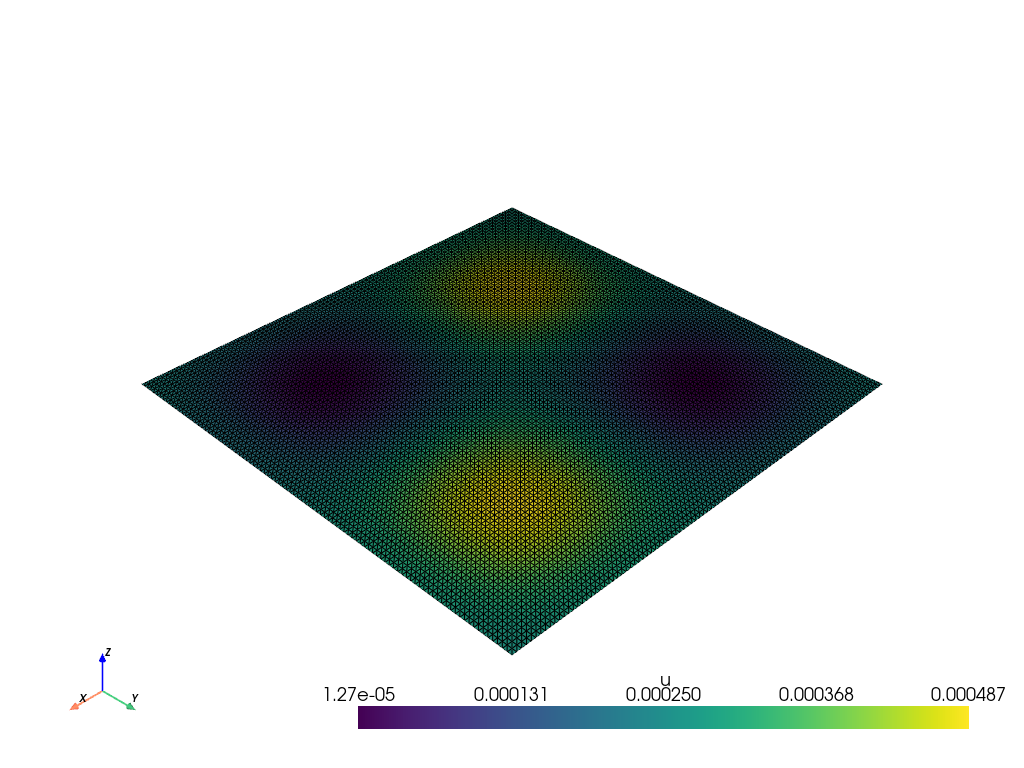

In [53]:
if have_pyvista:
    grid.point_data["c"] = u.x.array.real
    screenshot = out_folder / "ch.png" if pv.OFF_SCREEN else None
    pv.plot(grid, show_edges=True, screenshot=screenshot)